# Web Scraping & Analysis: Largest US Companies by Revenue

## 📌 Overview
This project demonstrates an end-to-end data workflow using Python. It involves scraping real-world data from Wikipedia, cleaning and transforming the dataset, and generating insights through visualization.

## 🎯 Objective
- Extract tabular data from a live website
- Convert HTML data into structured format using pandas
- Perform data cleaning and transformation
- Generate insights through visualization

## 🛠️ Tools & Libraries
- Python
- requests
- BeautifulSoup
- pandas
- matplotlib

## 🔹 Step 1: Import Required Libraries

In [138]:
# Importing libraries for web scraping and data processing

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

## 🔹 Step 2: Extract Data from Website

In [139]:
# Sending HTTP request to the Wikipedia page

url = "https://en.wikipedia.org/wiki/List_of_largest_companies_in_the_United_States_by_revenue"

In [140]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
}

page = requests.get(url, headers=headers)
if page.status_code != 200:
    raise Exception(f"Failed to fetch page. Status code: {page.status_code}")

In [141]:
# Parsing the HTML content using BeautifulSoup

soup = BeautifulSoup(page.text, 'html.parser')

In [142]:
# Finding all tables on the webpage
# Selecting the first table (contains company data)

soup.find_all('table', class_ = 'wikitable sortable')          

[<table class="wikitable sortable">
 <caption>
 </caption>
 <tbody><tr>
 <th>Rank
 </th>
 <th>Name
 </th>
 <th>Industry
 </th>
 <th>Revenue <br/>(USD millions)
 </th>
 <th>Revenue growth
 </th>
 <th>Employees
 </th>
 <th>Headquarters
 </th></tr>
 <tr>
 <td>1
 </td>
 <td><a href="/wiki/Walmart" title="Walmart">Walmart</a>
 </td>
 <td>Retail
 </td>
 <td style="text-align:center;">680,985
 </td>
 <td style="text-align:center;"><span typeof="mw:File"><span title="Increase"><img alt="Increase" class="mw-file-element" data-file-height="300" data-file-width="300" decoding="async" height="11" src="//upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Increase2.svg/20px-Increase2.svg.png" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Increase2.svg/40px-Increase2.svg.png 2x" width="11"/></span></span> <span data-sort-value="7000300000000000000♠" style="display:none"></span> 5.1%
 </td>
 <td style="text-align:center;">2,100,000
 </td>
 <td><a href="/wiki/Bentonville,_Arkansas" title="

In [143]:
# Selecting the relevant table (top companies by revenue)

table = soup.find('table', class_ = 'wikitable sortable')   

In [144]:
# Extracting column headers from the table
    
world_titles = table.find_all('th')

In [145]:
print(world_titles)

[<th>Rank
</th>, <th>Name
</th>, <th>Industry
</th>, <th>Revenue <br/>(USD millions)
</th>, <th>Revenue growth
</th>, <th>Employees
</th>, <th>Headquarters
</th>]


In [146]:
world_table_titles = [ title.text.strip() for title in world_titles ] 

print(world_table_titles)

['Rank', 'Name', 'Industry', 'Revenue (USD millions)', 'Revenue growth', 'Employees', 'Headquarters']


In [147]:
# Creating pandas DataFrame

df = pd.DataFrame(columns = world_table_titles)

df

,Rank,Name,Industry,Revenue (USD millions),Revenue growth,Employees,Headquarters


In [148]:
column_data = table.find_all('tr')

In [149]:
# Extracting row data from the table

for row in column_data[1:]:
    row_data = row.find_all('td')
    individual_row_data = [data.text.strip() for data in row_data]
    
    length = len(df)
    df.loc[length] = individual_row_data

In [150]:
# Preview the data

df

,Rank,Name,Industry,Revenue (USD millions),Revenue growth,Employees,Headquarters
0,1,Walmart,Retail,"680,985",5.1%,"2,100,000","Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,"637,959",11.0%,"1,556,000","Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,"400,278",7.7%,"400,000","Minnetonka, Minnesota"
3,4,Apple,Technology,"391,035",2.0%,"164,000","Cupertino, California"
4,5,CVS Health,Healthcare,"372,809",4.2%,"259,500","Woonsocket, Rhode Island"
...,...,...,...,...,...,...,...
95,96,General Dynamics,Aerospace and defense,"47,716",12.9%,"117,000","Reston, Virginia"
96,97,Coca-Cola,Beverage,"47,061",2.9%,"69,700","Atlanta, Georgia"
97,98,TIAA,Financials,"46,946",2.6%,"15,623","New York City, New York"
98,99,Travelers,Insurance,"46,423",12.2%,"34,000","New York City, New York"


In [151]:
# Saving the DataFrame to a CSV file

df.to_csv(r'C:\Users\shifi\OneDrive\Desktop\Portfolio_Project\Python\us_companies_data.csv', index = False)

## 🔹 Step 3: Data Cleaning & Transformation

After extracting the dataset, basic cleaning steps are performed to prepare the data for analysis and visualization

In [152]:
# Removing commas and converting revenue column into numeric format for analysis

df['Revenue (USD millions)'] = df['Revenue (USD millions)'].str.replace(',', '').astype(float)

## 📊 Step 4: Data Visualization

A visualization is created to identify the top 10 companies by revenue.

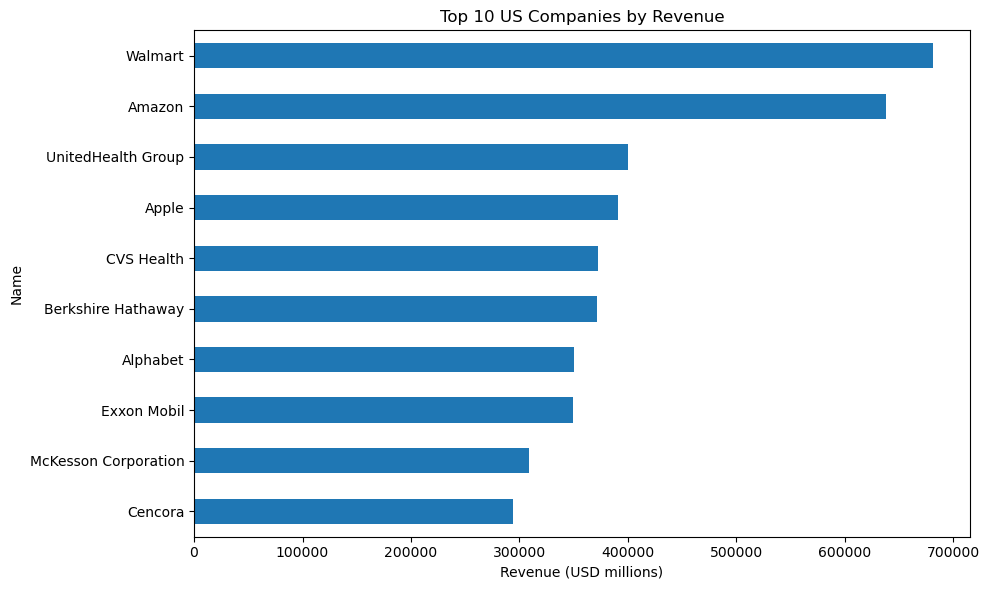

In [154]:
# Creating bar chart for top 10 companies by revenue

import matplotlib.pyplot as plt

# Bar chart of Top 10 US Companies by Revenue
top10 = df.nlargest(10, 'Revenue (USD millions)')

top10.plot(kind='barh', x='Name', y='Revenue (USD millions)', figsize=(10,6), legend=False)
plt.title('Top 10 US Companies by Revenue')
plt.gca().invert_yaxis() 
plt.xlabel('Revenue (USD millions)')
plt.tight_layout()
plt.show()

## ✅ Conclusion

This project demonstrates a complete data workflow, starting from web scraping to data cleaning and visualization.

The dataset was extracted from a real-world source and transformed into a structured format using pandas. Data cleaning ensured consistency, particularly in the revenue column, enabling accurate analysis.

The visualization highlights the top 10 companies by revenue, providing a clear business insight into market leaders.